# Training Visualization

Loss curve and eval metrics from `trainer_state.json`.

In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

In [12]:
TRAINER_STATE_PATH = Path("../saved_models/best_model/trainer_state.json")
OUTPUT_DIR         = Path("../outputs/plots")

In [13]:
def ema(values: np.ndarray, alpha: float = 0.05) -> np.ndarray:
    result = np.empty_like(values)
    result[0] = values[0]
    for i in range(1, len(values)):
        result[i] = alpha * values[i] + (1 - alpha) * result[i - 1]
    return result


def plot_training_curves(
    trainer_state_path: Path,
    output_path: Path | None = None,
) -> None:
    """
    3-panel summary of a training run:
      Top (full width) : train loss (raw + EMA) vs eval loss
      Bottom-left      : eval F1 macro/weighted, precision, recall
      Bottom-right     : learning-rate schedule
    Best-checkpoint line is drawn on the top two panels.
    """
    with open(trainer_state_path) as f:
        state = json.load(f)

    log_history = state["log_history"]
    best_step   = state.get("best_global_step")
    best_f1     = state.get("best_metric")

    train_logs = [e for e in log_history if "loss" in e and "eval_loss" not in e]
    eval_logs  = [e for e in log_history if "eval_loss" in e]

    train_steps = np.array([e["step"]          for e in train_logs])
    train_loss  = np.array([e["loss"]          for e in train_logs])
    train_lr    = np.array([e["learning_rate"] for e in train_logs])

    eval_steps     = np.array([e["step"]           for e in eval_logs])
    eval_loss      = np.array([e["eval_loss"]      for e in eval_logs])
    eval_f1        = np.array([e["eval_f1"]        for e in eval_logs])
    eval_f1w       = np.array([e["eval_f1_weighted"] for e in eval_logs])
    eval_precision = np.array([e["eval_precision"] for e in eval_logs])
    eval_recall    = np.array([e["eval_recall"]    for e in eval_logs])

    train_loss_smooth = ema(train_loss)

    # ── Layout ────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(14, 10))
    gs  = fig.add_gridspec(2, 2, hspace=0.40, wspace=0.30)
    ax_loss    = fig.add_subplot(gs[0, :])
    ax_metrics = fig.add_subplot(gs[1, 0])
    ax_lr      = fig.add_subplot(gs[1, 1])

    fmt_step = mticker.FuncFormatter(lambda x, _: f"{int(x):,}")

    # ── Panel 1: Loss ─────────────────────────────────────────────────
    ax_eloss = ax_loss.twinx()

    ax_loss.plot(train_steps, train_loss,        color="#ef4444", lw=0.5, alpha=0.20)
    ax_loss.plot(train_steps, train_loss_smooth, color="#ef4444", lw=1.8, alpha=0.90,
                 label="train loss (EMA)")
    ax_loss.set_ylabel("Train Loss", fontsize=9, color="#ef4444")
    ax_loss.tick_params(axis="y", labelcolor="#ef4444")
    ax_loss.spines[["top"]].set_visible(False)

    ax_eloss.plot(eval_steps, eval_loss, "o-", color="#38bdf8", lw=1.8, ms=6,
                  label="eval loss")
    ax_eloss.set_ylabel("Eval Loss", fontsize=9, color="#38bdf8")
    ax_eloss.tick_params(axis="y", labelcolor="#38bdf8")
    ax_eloss.spines[["top"]].set_visible(False)

    if best_step is not None:
        ax_loss.axvline(best_step, color="#a855f7", ls="--", lw=1.4,
                        label=f"best checkpoint  step {best_step:,}  F1={best_f1:.4f}")

    ax_loss.set_xlabel("Optimizer Step", fontsize=9)
    ax_loss.xaxis.set_major_formatter(fmt_step)
    ax_loss.grid(True, alpha=0.18, ls="--")
    ax_loss.set_title("Loss", fontsize=10, fontweight="bold")

    lines_t, labels_t = ax_loss.get_legend_handles_labels()
    lines_e, labels_e = ax_eloss.get_legend_handles_labels()
    ax_loss.legend(lines_t + lines_e, labels_t + labels_e, fontsize=8, loc="upper right")

    # ── Panel 2: Eval metrics ─────────────────────────────────────────
    ax_metrics.plot(eval_steps, eval_f1,        "o-", color="#a855f7", lw=1.6, ms=5, label="F1 macro")
    ax_metrics.plot(eval_steps, eval_f1w,       "s--",color="#818cf8", lw=1.4, ms=5, label="F1 weighted")
    ax_metrics.plot(eval_steps, eval_precision, "^-", color="#34d399", lw=1.4, ms=5, label="precision")
    ax_metrics.plot(eval_steps, eval_recall,    "v-", color="#fb923c", lw=1.4, ms=5, label="recall")

    if best_step is not None:
        ax_metrics.axvline(best_step, color="#a855f7", ls="--", lw=1.0, alpha=0.55)

    ax_metrics.set_xlabel("Optimizer Step", fontsize=9)
    ax_metrics.xaxis.set_major_formatter(fmt_step)
    ax_metrics.set_ylabel("Score", fontsize=9)
    ax_metrics.set_ylim(0, 1)
    ax_metrics.grid(True, alpha=0.18, ls="--")
    ax_metrics.spines[["top", "right"]].set_visible(False)
    ax_metrics.set_title("Eval Metrics", fontsize=10, fontweight="bold")
    ax_metrics.legend(fontsize=8)

    # ── Panel 3: Learning rate ────────────────────────────────────────
    ax_lr.plot(train_steps, train_lr, color="#facc15", lw=1.3)
    ax_lr.set_xlabel("Optimizer Step", fontsize=9)
    ax_lr.xaxis.set_major_formatter(fmt_step)
    ax_lr.set_ylabel("Learning Rate", fontsize=9)
    ax_lr.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2e"))
    ax_lr.grid(True, alpha=0.18, ls="--")
    ax_lr.spines[["top", "right"]].set_visible(False)
    ax_lr.set_title("Learning Rate Schedule", fontsize=10, fontweight="bold")

    fig.suptitle("SciBERT Training — Full Run Summary", fontsize=13, fontweight="bold")

    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=150, bbox_inches="tight")
        print(f"Saved → {output_path}")

    plt.show()

/tmp/ipykernel_811078/1947621176.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved → ../outputs/plots/training_curves.png


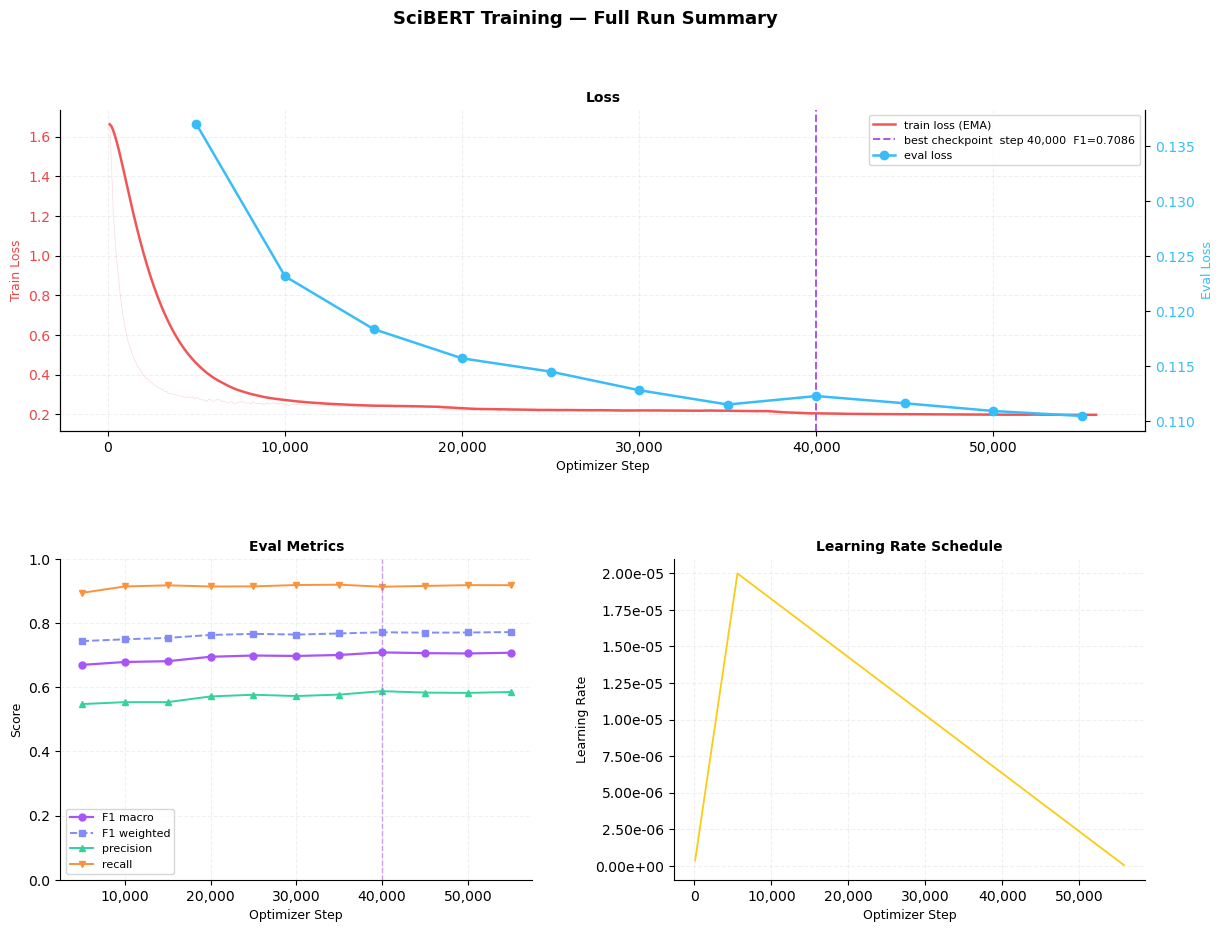

In [14]:
plot_training_curves(
    trainer_state_path=TRAINER_STATE_PATH,
    output_path=OUTPUT_DIR / "training_curves.png",
)